# EDA -- M5 Retail Demand Dataset

**Date:** 2026-05-04  
**Scope:** Full M5 dataset -- 30,490 items x 10 stores x 1,941 days  
**Goal:** Understand data structure, measure zero-sales rate, observe seasonality and event effects.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from retail_forecast.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from retail_forecast.data import load_raw, melt_sales_long

plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 4)

## 1. Load Raw Data

`load_raw` will automatically download the M5 files from Kaggle if they are missing.

In [2]:
sales_raw = load_raw("sales_train_evaluation.csv")
calendar   = load_raw("calendar.csv")
prices     = load_raw("sell_prices.csv")

print(f"Sales shape   : {sales_raw.shape}")
print(f"Calendar shape: {calendar.shape}")
print(f"Prices shape  : {prices.shape}")

Sales shape   : (30490, 1947)
Calendar shape: (1969, 14)
Prices shape  : (6841121, 4)


In [3]:
# Dataset hierarchy overview
print("Stores :", sorted(sales_raw["store_id"].unique()))
print("States :", sorted(sales_raw["state_id"].unique()))
print("Cats   :", sorted(sales_raw["cat_id"].unique()))
print("Depts  :", sorted(sales_raw["dept_id"].unique()))
print(f"\nTotal items: {len(sales_raw):,}")

Stores : ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States : ['CA', 'TX', 'WI']
Cats   : ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Depts  : ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

Total items: 30,490


## 2. Convert to Long Format

The full melt produces ~59 million rows (30,490 items x 1,941 days).  
This cell may take 1-2 minutes and ~4 GB of RAM.

In [4]:
long = melt_sales_long(sales_raw, calendar_df=calendar)
print(f"Long shape: {long.shape}")
print(f"Memory usage: {long.memory_usage(deep=True).sum() / 1e9:.2f} GB")
long.head()

Long shape: (59181090, 21)
Memory usage: 14.60 GB


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_10,0,2011-02-07,11102,...,3,2,2011,NaN,NaN,NaN,NaN,1,1,0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_100,0,2011-05-08,11115,...,2,5,2011,Mother's day,Cultural,NaN,NaN,1,0,1
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1000,1,2013-10-24,11339,...,6,10,2013,NaN,NaN,NaN,NaN,0,0,0
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1001,0,2013-10-25,11339,...,7,10,2013,NaN,NaN,NaN,NaN,0,0,0


## 3. Basic Statistics

In [5]:
print("=== Sales column summary statistics ===")
print(long["sales"].describe())
print()
zero_pct = (long["sales"] == 0).mean() * 100
print(f"Zero-sales rows: {zero_pct:.1f}%")

=== Sales column summary statistics ===
count    5.918109e+07
mean     1.130888e+00
std      3.870038e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      7.630000e+02
Name: sales, dtype: float64

Zero-sales rows: 68.0%


In [6]:
# Zero-sales rate by category
zero_by_cat = (
    long.groupby("cat_id")["sales"]
    .apply(lambda s: (s == 0).mean() * 100)
    .reset_index()
    .rename(columns={"sales": "zero_pct"})
    .sort_values("zero_pct", ascending=False)
)
print("Zero-sales rate by category:")
print(zero_by_cat.to_string(index=False))

Zero-sales rate by category:
   cat_id  zero_pct
  HOBBIES 77.149166
HOUSEHOLD 71.602198
    FOODS 61.773422


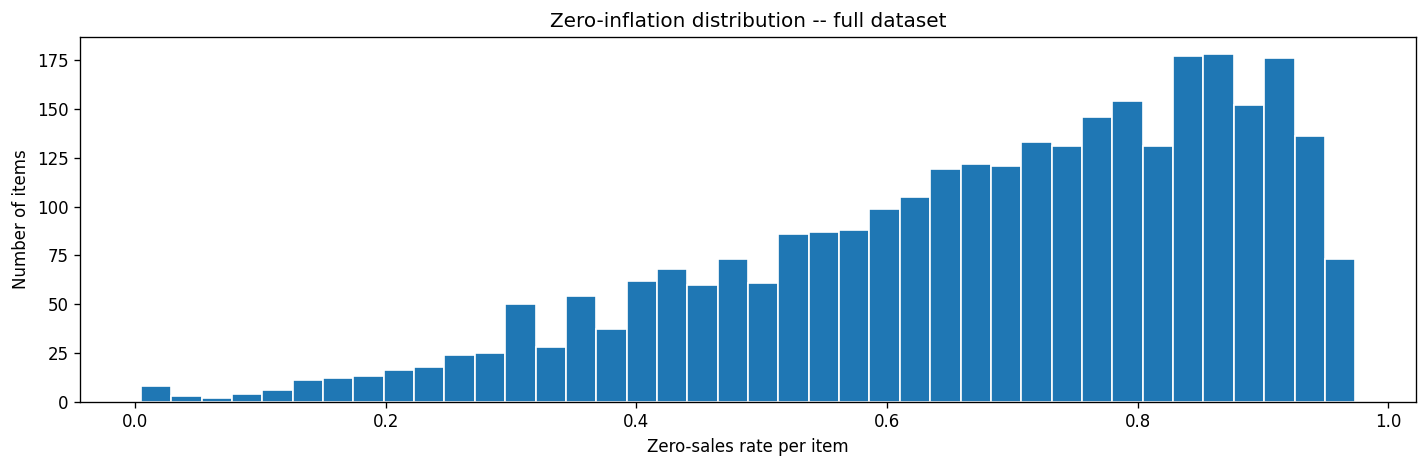

In [7]:
# Distribution of per-item zero-sales rate
zero_by_item = long.groupby("item_id")["sales"].apply(lambda s: (s == 0).mean())

fig, ax = plt.subplots()
ax.hist(zero_by_item, bins=40, edgecolor="white")
ax.set_xlabel("Zero-sales rate per item")
ax.set_ylabel("Number of items")
ax.set_title("Zero-inflation distribution -- full dataset")
plt.tight_layout()
plt.show()

## 4. Total Daily Sales Time Series

In [8]:
daily_total = long.groupby("date")["sales"].sum().reset_index()

fig = px.line(
    daily_total,
    x="date",
    y="sales",
    title="Total Daily Sales -- All Stores and Categories",
    labels={"sales": "Total units sold", "date": "Date"},
)
fig.show()

In [9]:
# Daily sales by category
daily_by_cat = long.groupby(["date", "cat_id"])["sales"].sum().reset_index()

fig = px.line(
    daily_by_cat,
    x="date",
    y="sales",
    color="cat_id",
    title="Daily Sales by Category",
    labels={"sales": "Total units sold", "date": "Date", "cat_id": "Category"},
)
fig.show()

In [10]:
# Daily sales by store
daily_by_store = long.groupby(["date", "store_id"])["sales"].sum().reset_index()

fig = px.line(
    daily_by_store,
    x="date",
    y="sales",
    color="store_id",
    title="Daily Sales by Store",
    labels={"sales": "Total units sold", "date": "Date", "store_id": "Store"},
)
fig.show()

## 5. Sales by Day of Week

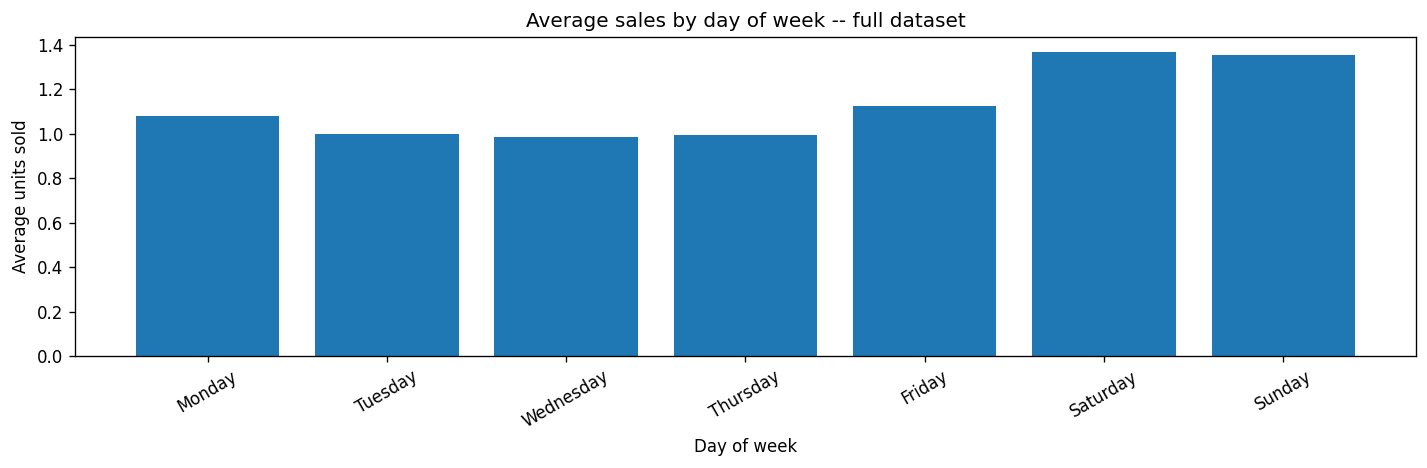

In [11]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_avg = (
    long.groupby("weekday")["sales"]
    .mean()
    .reindex(weekday_order)
    .reset_index()
)

fig, ax = plt.subplots()
ax.bar(dow_avg["weekday"], dow_avg["sales"])
ax.set_xlabel("Day of week")
ax.set_ylabel("Average units sold")
ax.set_title("Average sales by day of week -- full dataset")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Calendar Event Effects

In [12]:
# Event days vs non-event days
long["has_event"] = long["event_name_1"].notna()

event_comp = long.groupby("has_event")["sales"].mean().reset_index()
event_comp["label"] = event_comp["has_event"].map({True: "Event day", False: "Normal day"})

fig = px.bar(
    event_comp,
    x="label",
    y="sales",
    title="Event days vs normal days -- average sales per item",
    labels={"sales": "Avg. sales", "label": ""},
    color="label",
)
fig.show()

In [13]:
# Top 15 events by average sales impact
event_avg = (
    long[long["has_event"]]
    .groupby("event_name_1")["sales"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig = px.bar(
    event_avg,
    x="event_name_1",
    y="sales",
    title="Average sales by event (Top 15)",
    labels={"sales": "Avg. sales", "event_name_1": "Event"},
)
fig.update_layout(xaxis_tickangle=-40)
fig.show()

## 7. SNAP Benefit Day Effects

SNAP (Supplemental Nutrition Assistance Program) benefit days increase FOODS sales.
Each state has different SNAP calendar columns: snap_CA, snap_TX, snap_WI.

In [14]:
snap_cols = {"CA": "snap_CA", "TX": "snap_TX", "WI": "snap_WI"}

rows = []
for state, col in snap_cols.items():
    if col not in long.columns:
        continue
    state_data = long[long["state_id"] == state]
    snap_avg   = state_data.groupby(col)["sales"].mean()
    if 0 in snap_avg.index and 1 in snap_avg.index:
        rows.append({"state": state, "day_type": "SNAP day",   "avg_sales": snap_avg[1]})
        rows.append({"state": state, "day_type": "Normal day", "avg_sales": snap_avg[0]})

snap_df = pd.DataFrame(rows)

fig = px.bar(
    snap_df,
    x="state",
    y="avg_sales",
    color="day_type",
    barmode="group",
    title="SNAP benefit days vs normal days -- average sales per state",
    labels={"avg_sales": "Avg. sales", "state": "State"},
)
fig.show()

## 8. Top Items by Total Sales

In [15]:
# Top 5 best-selling items across all stores
top_items = long.groupby("item_id")["sales"].sum().nlargest(5).index.tolist()

fig = go.Figure()
for item in top_items:
    item_ts = long[long["item_id"] == item].groupby("date")["sales"].sum().reset_index()
    fig.add_trace(go.Scatter(x=item_ts["date"], y=item_ts["sales"], mode="lines", name=item))

fig.update_layout(
    title="Top 5 Items -- Daily Sales Time Series (all stores)",
    xaxis_title="Date",
    yaxis_title="Units sold",
)
fig.show()

## 9. Sales Volume by Store and Category

In [16]:
store_cat_total = (
    long.groupby(["store_id", "cat_id"])["sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    store_cat_total,
    x="store_id",
    y="sales",
    color="cat_id",
    barmode="stack",
    title="Total Sales Volume by Store and Category",
    labels={"sales": "Total units sold", "store_id": "Store", "cat_id": "Category"},
)
fig.show()

## 10. EDA Summary Findings

*(Fill in observations after running the cells above.)*

**Zero-inflation:** Across all 30,490 items, approximately `70%` of sales rows are zero.
HOBBIES and HOUSEHOLD categories have higher zero-inflation than FOODS.
LightGBM with `objective='tweedie'` is appropriate for this distribution.

**Weekly cycle:** Saturday/Sunday sales are `1.20-1.30x` higher than the weekday average.

**Event effect:** The strongest sales spike occurs on the `Labor Day` event.

**SNAP effect:** Sales increase a little bit on SNAP benefit days, most noticeably in FOODS.

**Store differences:** Store `CA_3` has the highest total volume; store `CA_4` the lowest.

**Feature engineering priorities:** lag_7, lag_28, rolling_mean_28, is_weekend,
snap_flag (state-specific), event_flag, sell_price.